# EyePACS Dataset Visualization

This notebook loads and visualizes 20 sample images from the original EyePACS dataset (before preprocessing).

The dataset is loaded directly from Hugging Face (`bumbledeep/eyepacs`) and displays images in a 4×5 grid collage.


In [1]:
# Import necessary libraries
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Loading original dataset images from Hugging Face...")


Loading original dataset images from Hugging Face...


In [2]:
# Load the EyePACS dataset from Hugging Face
dataset = load_dataset("bumbledeep/eyepacs", split="train")

print(f"Dataset loaded: {len(dataset)} samples")
print(f"Dataset features: {dataset.features}")


Dataset loaded: 35108 samples
Dataset features: {'image': Image(mode=None, decode=True), 'label_code': Value('int64'), 'label': Value('string')}


In [ ]:
# Class mapping for labels
CLASS_NAMES = {
    0: "No Diabetic Retinopathy",
    1: "Mild Retinopathy",
    2: "Moderate Retinopathy",
    3: "Severe Retinopathy",
    4: "Proliferative Retinopathy"
}

# String label to numeric mapping (from dataset)
STRING_TO_NUMERIC = {
    "no_diabetic_retinopathy": 0,
    "mild_retinopathy": 1,
    "moderate_retinopathy": 2,
    "severe_retinopathy": 3,
    "proliferative_retinopathy": 4
}

# Select 20 random samples from the dataset
np.random.seed(42)
num_samples = 20
indices = np.random.choice(len(dataset), num_samples, replace=False)

print(f"Selected {num_samples} random samples from the dataset")


Selected 20 random samples from the dataset


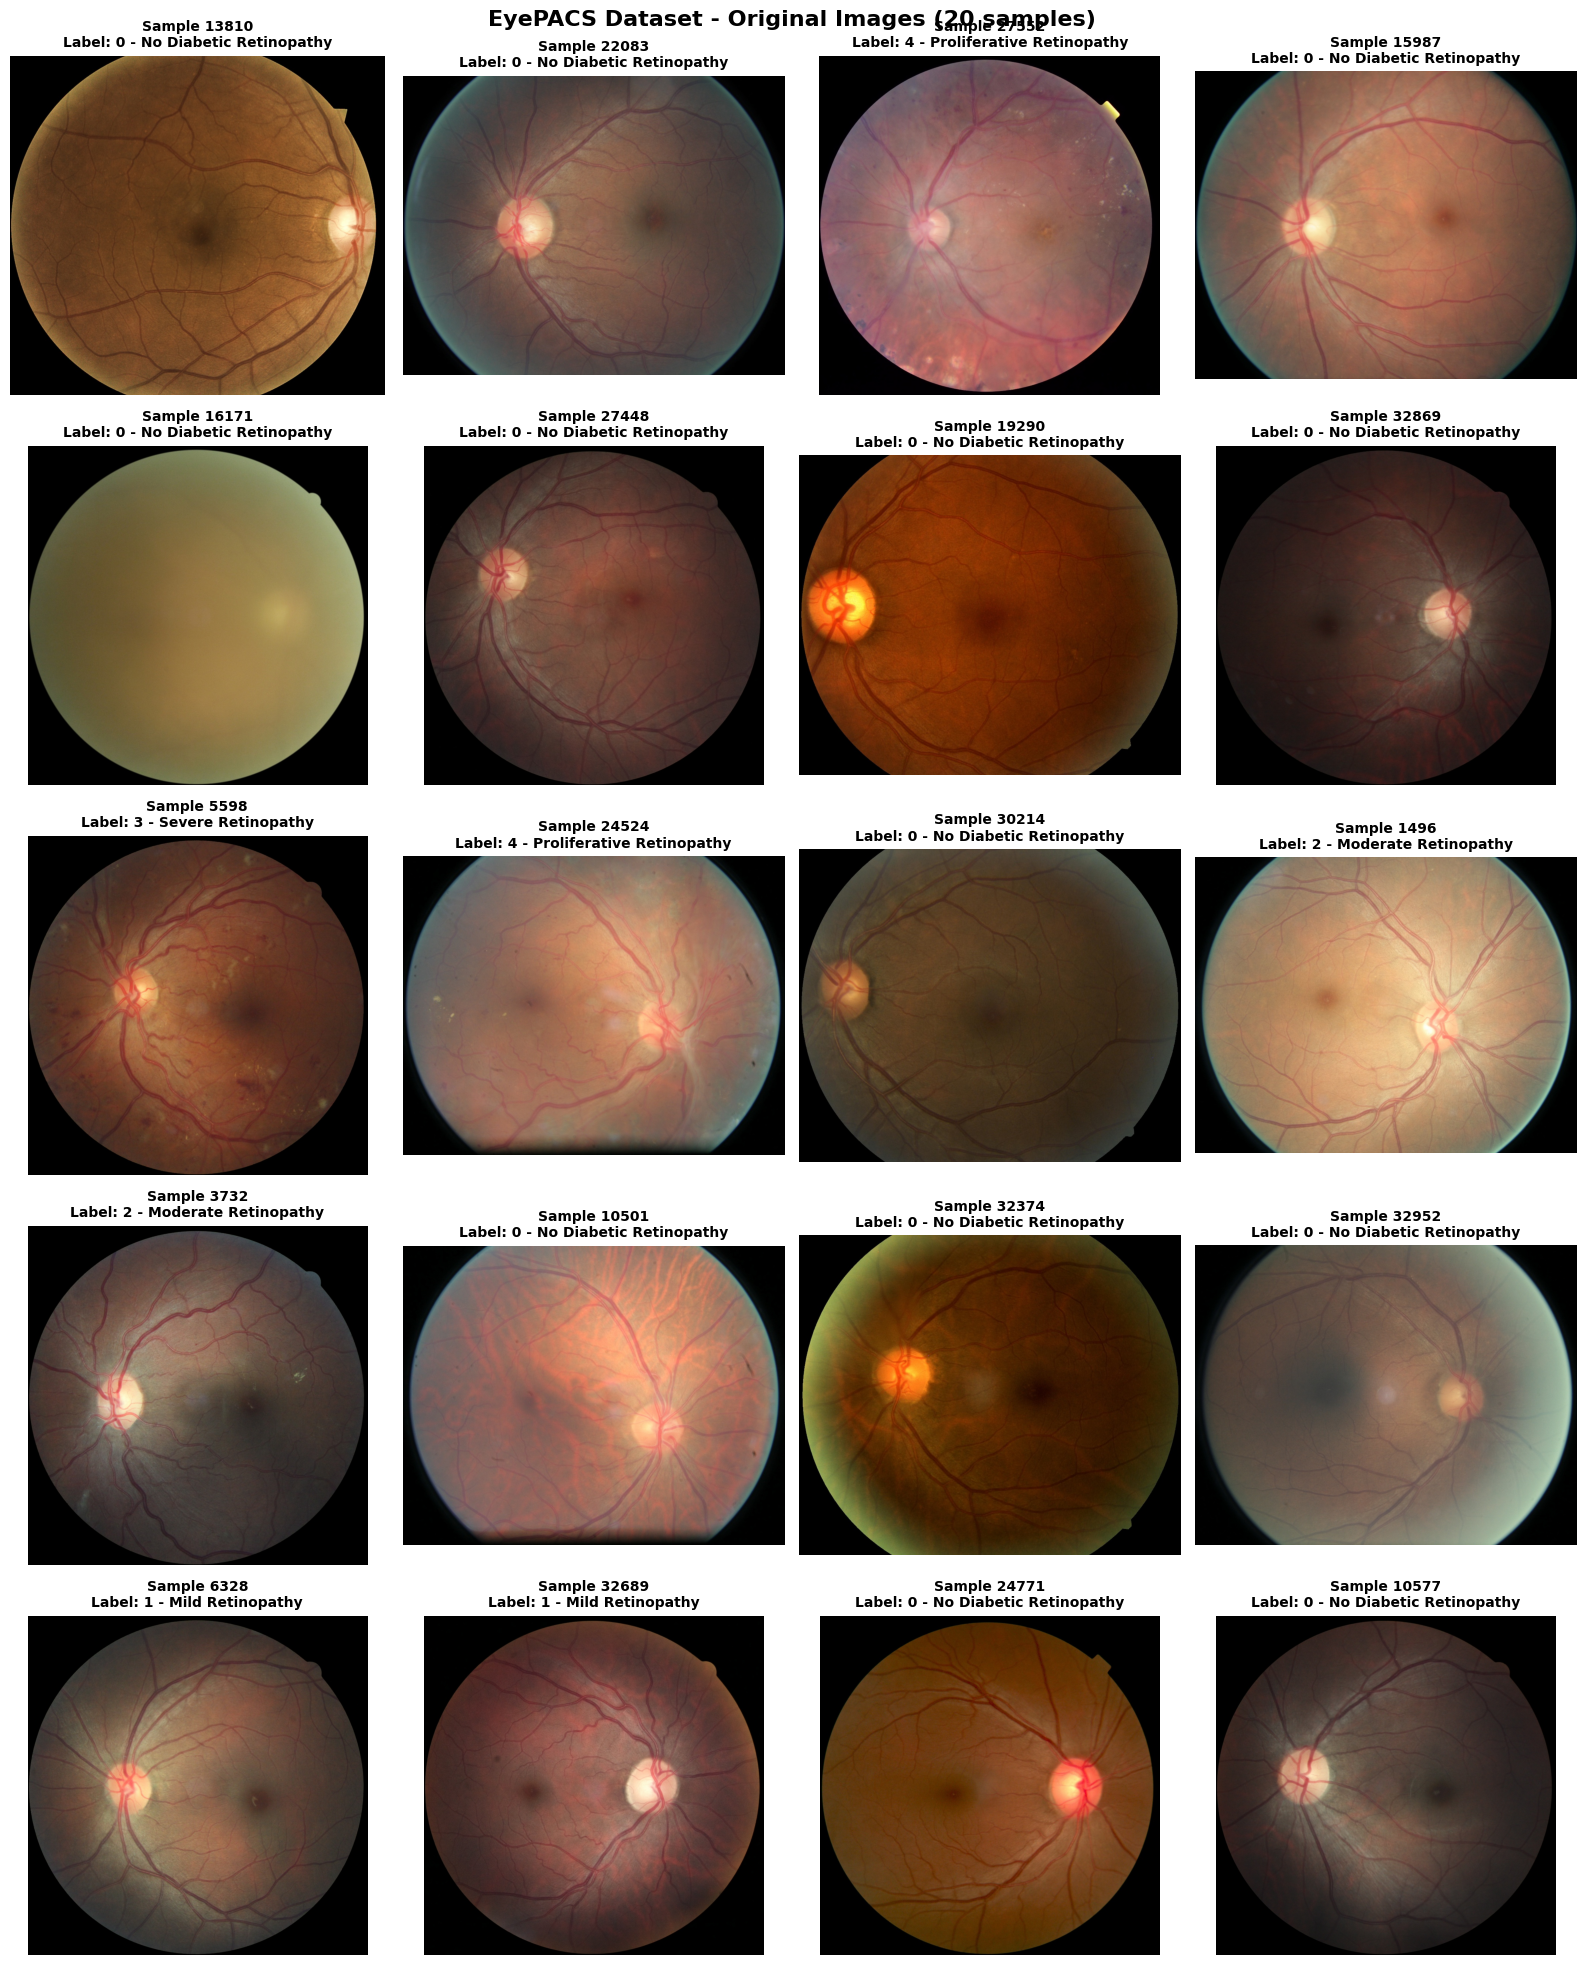


Displayed 20 images from the original EyePACS dataset
Each image shows the sample index, label code, and class name


In [5]:
# Create a 4×5 grid collage (4 columns × 5 rows = 20 images)
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
fig.suptitle('EyePACS Dataset - Original Images (20 samples)', fontsize=16, fontweight='bold')

# Flatten axes array for easier indexing
axes = axes.flatten()

# Display each image
for idx, sample_idx in enumerate(indices):
    sample = dataset[sample_idx]
    image = sample["image"]  # PIL Image
    
    # Get label - prefer label_code (integer), fallback to label (string)
    if "label_code" in sample:
        label_code = sample["label_code"]
        label_str = sample.get("label", CLASS_NAMES[label_code])
    else:
        # If only string label exists, convert it
        label_str = sample["label"]
        label_code = STRING_TO_NUMERIC.get(label_str.lower(), -1)
    
    # Display image
    axes[idx].imshow(image)
    if label_code >= 0:
        title = f'Sample {sample_idx}\nLabel: {label_code} - {CLASS_NAMES[label_code]}'
    else:
        title = f'Sample {sample_idx}\nLabel: {label_str}'
    axes[idx].set_title(title, fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nDisplayed {num_samples} images from the original EyePACS dataset")
print(f"Each image shows the sample index, label code, and class name")
